## Imports das Bibliotecas

In [48]:
## Imports Geral
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import nltk
import numpy as np 

# Import para Visualização de Dados
from wordcloud import WordCloud

# Extração de Texto
from nltk.corpus import stopwords

# Importações de Metrica
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Preprocessamento
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

import warnings

# Suprimir todos os warnings
warnings.filterwarnings("ignore")

# DESENVOLVER O MODELO SEM VIES 

# Analise dos dados

In [49]:
df1 = pd.read_csv("./datasets/Coleta_Brancas.csv")
df2 = pd.read_csv("./datasets/Coleta_Negras.csv")
df3 = pd.read_csv("./datasets/Coleta_Pardas.csv")

df = pd.concat([df1, df2, df3])

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1226 entries, 0 to 370
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Name           1226 non-null   object
 1   Original_Text  1226 non-null   object
 2   Cor            1226 non-null   object
 3   Conclusao      359 non-null    object
dtypes: object(4)
memory usage: 47.9+ KB


In [50]:
df = df.rename(columns={'Name': 'name', 'Original_Text':'ementa' , 'Cor': 'cor', 'Conclusao': 'conclusao'})
df['conclusao'] = df['conclusao'].fillna('VAZIO')
df

,name,ementa,cor,conclusao
0,Adilson Candido Da Silva,\nExcelentíssimo(a) Senhor(a) Doutor(a) Juiz(a...,Branca,VAZIO
1,Adilson Candido Da Silva,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA ...,Branca,VAZIO
2,Adilson Candido Da Silva,EXCELENTÍSSIMO SENHOR DOUTOR JUIZ DE DIREITO ...,Branca,VAZIO
3,Adilson Candido Da Silva,\nFls.: 2\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ D...,Branca,GANHO
4,Adilson Candido Da Silva,EXMO. SR. DR. JUIZ DE DIREITO DA 7º VARA CÍVE...,Branca,PERDIDO
...,...,...,...,...
366,Weber Lasaro De Oliveira,\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA...,Parda,AMBIGUO
367,Weber Lasaro De Oliveira,\nEXCELENTÍSSIMO SENHOR DOUTOR JUIZ FEDERAL DA...,Parda,AMBIGUO
368,Wilson Jose De Araujo,AO JUÍZO DE DIREITO DA VARA DO JUIZADO ESPECI...,Parda,VAZIO
369,Wilson Jose De Araujo,\nEXCELENTÍSSIMA SENHORA DOUTORA JUÍZA DE DIRE...,Parda,PERDIDO


In [51]:
# Remova duplicatas apenas da coluna A e concatene os valores correspondentes em uma única instância
df = df.groupby('name').agg(lambda x: ', '.join(x.unique())).reset_index()

In [52]:
df['cor'].value_counts()

cor
Branca    86
Parda     56
Negra     23
Name: count, dtype: int64

In [53]:
# # y_pred = model_LR.predict(X)
# # rng = np.random.default_rng(42)
# rng = np.random.default_rng(62)
# numbers = rng.random(len(df))
# balanceamento = [df.loc[df["cor"] == "BRANCA"].sample(1)  if i < prob_brancos else df.loc[df['cor'] == 'OUTROS'].sample(1) for i in numbers]
# df = pd.concat(balanceamento)


In [54]:
# df["nome"].value_counts().unique()
df["ementa"].count()

165

In [55]:
cor = df["cor"].value_counts().reset_index()
cor["cor"].unique()
cor

,cor,count
0,Branca,86
1,Parda,56
2,Negra,23


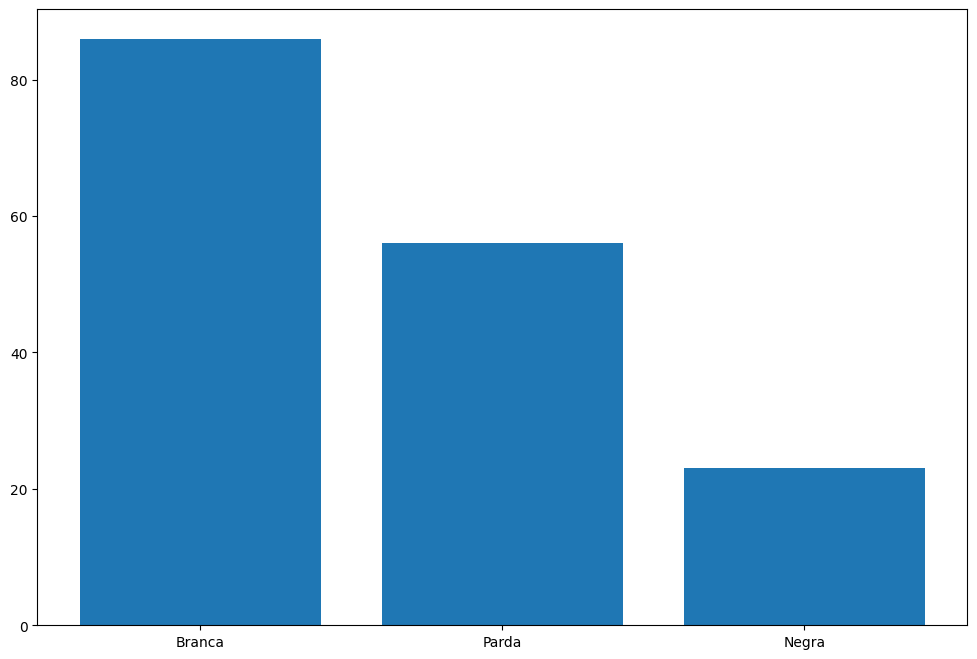

In [56]:
fx, ax = plt.subplots(1, 1, figsize=(12, 8))
ax.bar(cor["cor"], height=cor["count"])
plt.show()

In [57]:
df["ementa"].dropna().count()

165

## Bag Of Words

In [58]:
# nltk.download('stopwords')

In [59]:
stop_words = list(stopwords.words('portuguese'))

stopword = ['00', '00b', '00da', '0000do', 'ao', '00do', '00no', '00ao', '00mai', '00pelo', '00extra', '00pago', '2oo', '00o']

for i in stopword:
    stop_words.append(i)

In [60]:
df = df.dropna(subset=["ementa"]).reset_index(drop=True)

In [61]:
tf_idf = TfidfVectorizer(stop_words=list(stop_words), ngram_range=(1,1) )
X = tf_idf.fit_transform(df["ementa"])
vocab = tf_idf.get_feature_names_out()
vocab = ' '.join(vocab)


In [62]:
print(list(stop_words))


['a', 'à', 'ao', 'aos', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aquilo', 'as', 'às', 'até', 'com', 'como', 'da', 'das', 'de', 'dela', 'delas', 'dele', 'deles', 'depois', 'do', 'dos', 'e', 'é', 'ela', 'elas', 'ele', 'eles', 'em', 'entre', 'era', 'eram', 'éramos', 'essa', 'essas', 'esse', 'esses', 'esta', 'está', 'estamos', 'estão', 'estar', 'estas', 'estava', 'estavam', 'estávamos', 'este', 'esteja', 'estejam', 'estejamos', 'estes', 'esteve', 'estive', 'estivemos', 'estiver', 'estivera', 'estiveram', 'estivéramos', 'estiverem', 'estivermos', 'estivesse', 'estivessem', 'estivéssemos', 'estou', 'eu', 'foi', 'fomos', 'for', 'fora', 'foram', 'fôramos', 'forem', 'formos', 'fosse', 'fossem', 'fôssemos', 'fui', 'há', 'haja', 'hajam', 'hajamos', 'hão', 'havemos', 'haver', 'hei', 'houve', 'houvemos', 'houver', 'houvera', 'houverá', 'houveram', 'houvéramos', 'houverão', 'houverei', 'houverem', 'houveremos', 'houveria', 'houveriam', 'houveríamos', 'houvermos', 'houvesse', 'houvessem', 'houvésse

## WORD CLOUD

In [63]:
le = LabelEncoder()

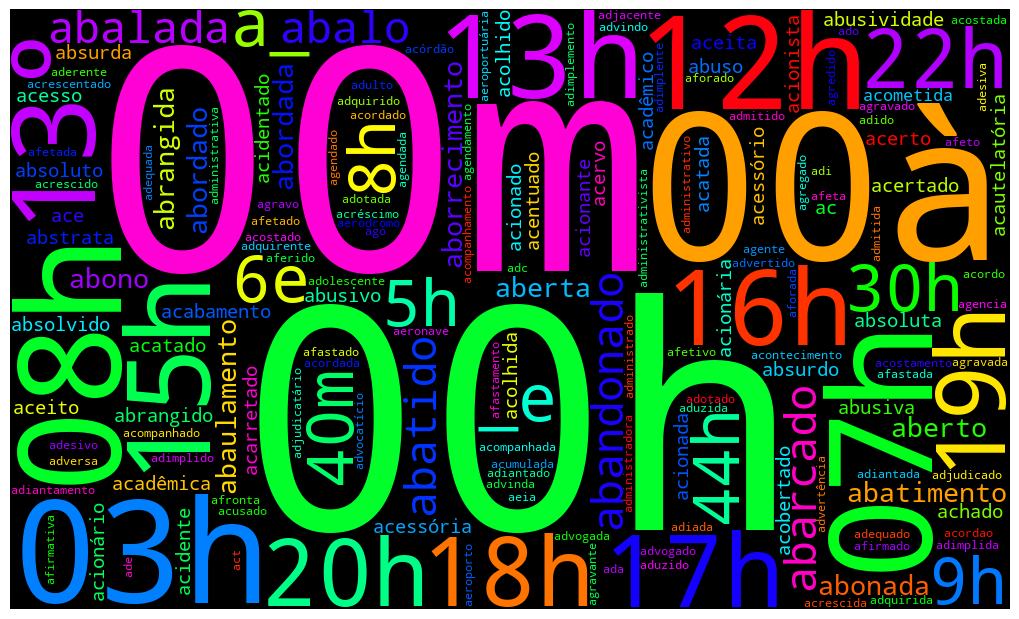

In [64]:
# Juntar as strings em uma única string separada por espaços
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1000,
    height=600,
    background_color='black',
    colormap='gist_rainbow',
    min_font_size=10).generate(vocab)

plt.figure(figsize=(10, 6), facecolor=None)
plt.imshow(wordcloud)
plt.axis('off')
plt.tight_layout(pad=0)
plt.show()

In [65]:
le = LabelEncoder()

df["cor"] = le.fit_transform(df["cor"])
y = df["cor"]

## Treino do Modelo

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
from imblearn.over_sampling import SMOTE

# transform the dataset
oversample = SMOTE()
X_train, y_train = oversample.fit_resample(X_train, y_train)

In [68]:
## Funçao para Avaliação dos Modelos

def evaluation_parametrics(name, y_test, y_pred):
    cm_test = confusion_matrix(y_test, y_pred)
    
    t1 = ConfusionMatrixDisplay(cm_test, display_labels=[
                                "Branca", 'Pardos', 'Negros'])
    print("Classification Report for Data Test")
    print(classification_report(y_test, y_pred))
    t1.plot()

In [69]:
#K Fold

K = 5
kf = KFold(n_splits=K, shuffle=False) 

# Logistic Regression

In [70]:
model_LR = LogisticRegression(random_state=42, max_iter=1000, solver="liblinear", penalty="l2", C=3, tol=0.001)
cross_val_results_f1_scoreLR = cross_val_score(model_LR, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyLR = cross_val_score(model_LR, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreLR)


print("Media da Accuracy: ", cross_val_results_accuracyLR.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreLR.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreLR.std())

Resultado da Cross Validation:  [0.29112834 0.26861702 0.4225     0.1969697  0.1300813 ]
Media da Accuracy:  0.4424242424242424
Media da MACRO F1:  0.26185927133985326
Desvio Padrão da MACRO F1:  0.09826889590187211


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.54      0.88      0.67        16
           1       0.00      0.00      0.00         3
           2       0.50      0.07      0.12        14

    accuracy                           0.45        33
   macro avg       0.35      0.32      0.26        33
weighted avg       0.47      0.45      0.38        33



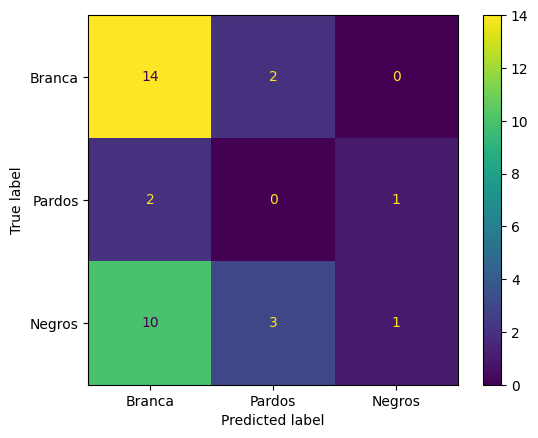

In [71]:
model_LR.fit(X_train, y_train)
y_pred = model_LR.predict(X_test)
evaluation_parametrics("Machine Learning - Logistic", y_test, y_pred)

# SGD Classifier

In [72]:
model_SGD = SGDClassifier(random_state=42, loss="squared_hinge", alpha=0.0001, learning_rate="constant", eta0=0.1, power_t=0.5, penalty="l2", tol=0.001, early_stopping=True, n_jobs=-1, class_weight="balanced")
cross_val_results_f1_scoreSGD = cross_val_score(model_SGD, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracySGD = cross_val_score(model_SGD, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreSGD)

print("Media da Accuracy: ", cross_val_results_accuracySGD.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreSGD.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreSGD.std())

Resultado da Cross Validation:  [0.31039136 0.17094017 0.28888889 0.225      0.13675214]
Media da Accuracy:  0.3696969696969697
Media da MACRO F1:  0.2263945119208277
Desvio Padrão da MACRO F1:  0.0664438141149009


# K Neighbors Classifier

In [73]:
model_KNeighbors = KNeighborsClassifier(n_neighbors=5, weights="distance", algorithm="auto", leaf_size=50, p=2 )
cross_val_results_f1_scoreKN = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="f1_macro", )
cross_val_results_accuracyKN = cross_val_score(model_KNeighbors, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreKN)

print("Media da Accuracy: ", cross_val_results_accuracyKN.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreKN.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreKN.std())

Resultado da Cross Validation:  [0.21114594 0.11658456 0.1087344  0.29429635 0.15925926]
Media da Accuracy:  0.19393939393939394
Media da MACRO F1:  0.1780041032160174
Desvio Padrão da MACRO F1:  0.06862111583584683


Classification Report for Data Test
              precision    recall  f1-score   support

           0       1.00      0.06      0.12        16
           1       0.07      0.67      0.13         3
           2       0.00      0.00      0.00        14

    accuracy                           0.09        33
   macro avg       0.36      0.24      0.08        33
weighted avg       0.49      0.09      0.07        33



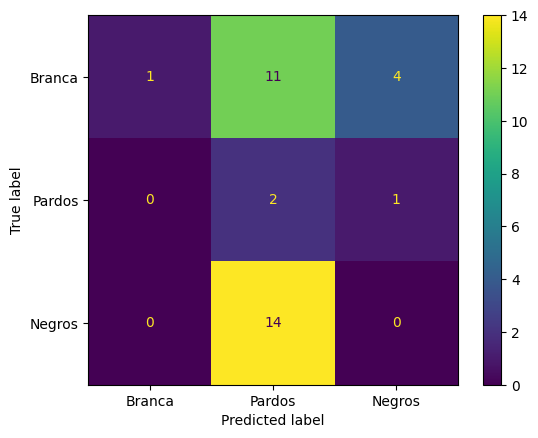

In [74]:
model_KNeighbors.fit(X_train, y_train)
y_pred = model_KNeighbors.predict(X_test)
evaluation_parametrics("Machine Learning - K Neighbors", y_test, y_pred)

# SVM (SUPPORT VECTOR MACHINE)

In [75]:
model_SVM = LinearSVC(random_state=42, loss='squared_hinge', max_iter=1000, penalty="l2", C=3, tol=0.0001, multi_class='ovr', dual=True, class_weight="balanced",  )
cross_val_results_f1_scoreSVM = cross_val_score(model_SVM, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracySVM = cross_val_score(model_SVM, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreSVM)

print("Media da Accuracy: ", cross_val_results_accuracySVM.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreSVM.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreSVM.std())

Resultado da Cross Validation:  [0.34528934 0.21937984 0.23030303 0.16666667 0.15511163]
Media da Accuracy:  0.37575757575757573
Media da MACRO F1:  0.22335010210994674
Desvio Padrão da MACRO F1:  0.06753189350143972


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.48      0.75      0.59        16
           1       0.00      0.00      0.00         3
           2       0.50      0.14      0.22        14

    accuracy                           0.42        33
   macro avg       0.33      0.30      0.27        33
weighted avg       0.44      0.42      0.38        33



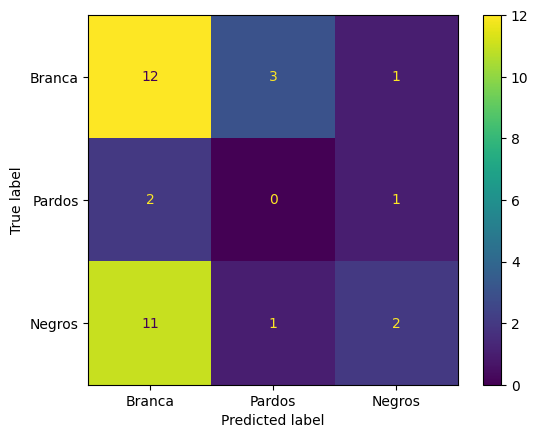

In [76]:
model_SVM.fit(X_train, y_train)
y_pred = model_SVM.predict(X_test)
evaluation_parametrics("Machine Learning - SVM", y_test, y_pred)

# Random Forest

In [77]:
model_Random_Forest = RandomForestClassifier(random_state=42, n_estimators=500, criterion="gini", max_features='sqrt', class_weight='balanced', n_jobs=-1, )
cross_val_results_f1_scoreRF = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyRF = cross_val_score(model_Random_Forest, X, y, cv=kf, scoring="accuracy")


print("Resultado da Cross Validation: ", cross_val_results_f1_scoreRF)

print("Media da Accuracy: ", cross_val_results_accuracyRF.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreRF.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreRF.std())

Resultado da Cross Validation:  [0.24489796 0.29128205 0.37735849 0.28684003 0.1300813 ]
Media da Accuracy:  0.49090909090909085
Media da MACRO F1:  0.2660919666731306
Desvio Padrão da MACRO F1:  0.0804901845915625


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.50      0.81      0.62        16
           1       0.00      0.00      0.00         3
           2       0.43      0.21      0.29        14

    accuracy                           0.48        33
   macro avg       0.31      0.34      0.30        33
weighted avg       0.42      0.48      0.42        33



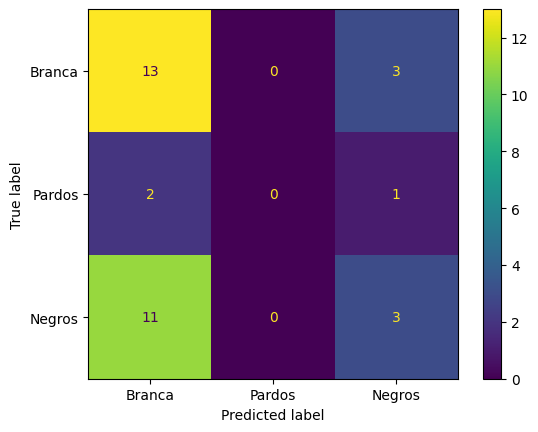

In [78]:
model_Random_Forest.fit(X_train, y_train)
y_pred = model_Random_Forest.predict(X_test)
evaluation_parametrics("Machine Learning - Random Forest", y_test, y_pred)

# Decision Tree

In [79]:
model_Decision_Tree = DecisionTreeClassifier(random_state=42, criterion="entropy", splitter="random", class_weight="balanced", ccp_alpha=0.0001)

cross_val_results_f1_scoreDT = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="f1_macro")
cross_val_results_accuracyDT = cross_val_score(model_Decision_Tree, X, y, cv=kf, scoring="accuracy")

print("Resultado da Cross Validation: ", cross_val_results_f1_scoreDT)

print("Media da Accuracy: ", cross_val_results_accuracyDT.mean())
print("Media da MACRO F1: ", cross_val_results_f1_scoreDT.mean())
print("Desvio Padrão da MACRO F1: ", cross_val_results_f1_scoreDT.std())

Resultado da Cross Validation:  [0.29868578 0.2505978  0.22312191 0.33928571 0.41013825]
Media da Accuracy:  0.40606060606060607
Media da MACRO F1:  0.30436589062369446
Desvio Padrão da MACRO F1:  0.06622845590320944


Classification Report for Data Test
              precision    recall  f1-score   support

           0       0.40      0.38      0.39        16
           1       0.00      0.00      0.00         3
           2       0.40      0.43      0.41        14

    accuracy                           0.36        33
   macro avg       0.27      0.27      0.27        33
weighted avg       0.36      0.36      0.36        33



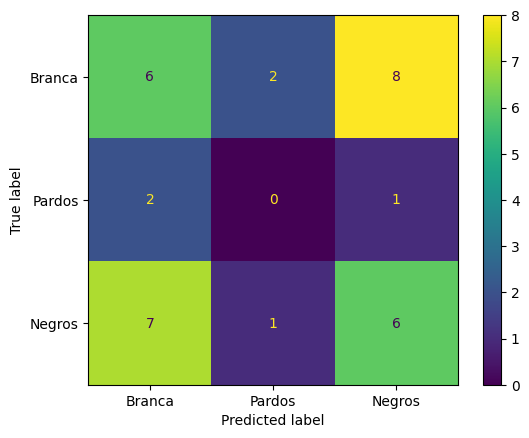

In [80]:
model_Decision_Tree.fit(X_train, y_train)
y_pred = model_Decision_Tree.predict(X_test)
evaluation_parametrics("Machine Learning - Decision Tree", y_test, y_pred)

In [81]:
## Funçao para Avaliação dos Modelos
# Refazer essa parte 
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

branca:int = df["cor"].loc[(df["cor"] == 0)].value_counts()
# print(int(branca))
prob_branca = (int(branca)/len(df["cor"]))

parda:int = df["cor"].loc[(df["cor"] == 1)].value_counts()

prob_parda = (int(parda)/len(df["cor"]))

negra:int = df["cor"].loc[(df["cor"] == 2)].value_counts()

prob_negra = (int(negra)/len(df["cor"]))


result_sem_vies_accuracy = []
result_sem_vies_macro_f1 = []
rng_options = [8, 32, 42, 64, 128]
for _ in range(5):
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    sem_vies = []
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))

    for i in numbers:

        if i < prob_branca:
            aux = df.loc[df["cor"] == 0].sample(1)

        elif i > prob_branca and i < prob_branca + prob_parda:
            aux = df.loc[df["cor"] == 2].sample(1)

        elif i > prob_branca + prob_parda:
            aux = df.loc[df["cor"] == 1].sample(1)

        sem_vies.append(aux)

    new_df = pd.concat(sem_vies)  
        
    result_sem_vies_macro_f1.append(f1_score(y_test, new_df['cor'], average='macro'))
    result_sem_vies_accuracy.append(accuracy_score(y_test, new_df['cor']))

In [82]:
print(f' Média da Acurácia: {sum(result_sem_vies_accuracy)/len(result_sem_vies_accuracy)}')
print(f' Média da Macro F1: {sum(result_sem_vies_macro_f1)/len(result_sem_vies_macro_f1)}')

 Média da Acurácia: 0.3878787878787878
 Média da Macro F1: 0.3240156323438057


# Aleatório

In [83]:
df['cor'].value_counts()

cor
0    86
2    56
1    23
Name: count, dtype: int64

In [84]:
y_test.count()

33

In [85]:
resultado_aleatorio_accuracy = []
resultado_aleatorio_f1_score = []
rng_options = [8, 32, 42, 64, 128]

for _ in range(5):
    aleatorio = []
    rng = np.random.default_rng(rng_options[_])
    numbers = rng.random(len(y_test))
    y_test1 = y_test

    for i in range(int((len(numbers))/3)):
        aleatorio.append(y_train.loc[y_train == 0].sample(1))
        aleatorio.append(y_train.loc[y_train == 1].sample(1))
        aleatorio.append(y_train.loc[y_train == 2].sample(1))

    new_df = pd.concat(aleatorio)
    resultado_aleatorio_accuracy.append(accuracy_score(y_test1, new_df))
    resultado_aleatorio_f1_score.append(f1_score(y_test1, new_df, average='macro'))


In [86]:
resultado_aleatorio_accuracy

[0.2727272727272727,
 0.2727272727272727,
 0.2727272727272727,
 0.2727272727272727,
 0.2727272727272727]

In [87]:
resultado_aleatorio_f1_score

[0.23209876543209876,
 0.23209876543209876,
 0.23209876543209876,
 0.23209876543209876,
 0.23209876543209876]

# P_VALUE

# LOGISTIC REGRESSION

In [88]:
from scipy.stats import ttest_rel

ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyLR)

TtestResult(statistic=-2.927166891540174, pvalue=0.0429350310390642, df=4)

# SGD

In [89]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracySGD)

TtestResult(statistic=-2.138089935299396, pvalue=0.09930068321372666, df=4)

# KNN

In [90]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyKN)

TtestResult(statistic=1.9598237397554632, pvalue=0.12157920965640186, df=4)

# SVM

In [91]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracySVM)

TtestResult(statistic=-2.16776082441535, pvalue=0.09605055602703362, df=4)

# Random Forest

In [92]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyRF)

TtestResult(statistic=-3.342516087186934, pvalue=0.028768335227558006, df=4)

# Decision Tree

In [93]:
ttest_rel(resultado_aleatorio_accuracy, cross_val_results_accuracyDT)

TtestResult(statistic=-8.629109946080101, pvalue=0.0009916791152611367, df=4)

# Sem Vies

In [94]:
ttest_rel(resultado_aleatorio_accuracy, result_sem_vies_accuracy)

TtestResult(statistic=-2.9673014758835152, pvalue=0.041254503584114234, df=4)